# Лабораторная работа 1. Анализ тональности на основе BERT

### Задание 1. Получение оценок качества с классической моделью BERT
В этом задании требуется получить оценки качества на обучающих данных Kaggle (https://www.kaggle.com/c/sentiment-analysis-in-russian/data) с применением модели `RuBERT` на основе отложенной выборки или кросс-валидации.  

При выполнении задания можно воспользоваться предоставленным ноутбуком (`huggingface_bert_finetuning`).  
Подберите гиперпараметры (по крайней мере, количество эпох).  

Выведите результаты и время построения моделей в удобном табличном виде, а также в виде графиков.

In [6]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
import time
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\giezz\PycharmProjects\m_nlp_course_vyatsu\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
def load_data(file_path):
    df = pd.read_json(file_path)
    return df

train_df = load_data('./data/train.json')
test_df = load_data('./data/test.json')

print(f"Размер обучающей выборки: {len(train_df)}")
print(f"Размер тестовой выборки: {len(test_df)}")
print(f"\nРаспределение классов в обучающей выборке:")
print(train_df['sentiment'].value_counts())

Размер обучающей выборки: 8263
Размер тестовой выборки: 2056

Распределение классов в обучающей выборке:
sentiment
neutral     4034
positive    2795
negative    1434
Name: count, dtype: int64


In [8]:
model_name = "cointegrated/rubert-tiny2"  # Using a lightweight RuBERT model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(train_df['sentiment'].unique())
)


C:\Users\giezz\PycharmProjects\m_nlp_course_vyatsu\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\giezz\.cache\huggingface\hub\models--cointegrated--rubert-tiny2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falli

In [9]:
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])
        label = self.labels.iloc[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

    def __len__(self):
        return len(self.texts)

# Encode labels
label_to_id = {label: i for i, label in enumerate(train_df['sentiment'].unique())}
id_to_label = {i: label for label, i in label_to_id.items()}

train_df['label_encoded'] = train_df['sentiment'].map(label_to_id)

# Split the training data
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df['text'],
    train_df['label_encoded'],
    test_size=0.2,
    random_state=42,
    stratify=train_df['label_encoded']
)

train_dataset = SentimentDataset(train_texts, train_labels, tokenizer)
val_dataset = SentimentDataset(val_texts, val_labels, tokenizer)

In [10]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1': f1_score(labels, predictions, average='weighted')
    }


In [11]:
results = []

# Experiment with different number of epochs
for epochs in [2, 3, 4]:
    print(f"\nTraining with {epochs} epochs...")

    training_args = TrainingArguments(
        output_dir='./results',
        overwrite_output_dir=True,
        num_train_epochs=epochs,
        per_device_train_batch_size=2,
        per_device_eval_batch_size=2,
        eval_strategy='epoch',
        save_strategy="epoch",
        logging_dir='./logs',
        logging_steps=10,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        disable_tqdm=False,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
    )

    start_time = time.time()
    trainer.train()
    training_time = time.time() - start_time

    # Evaluate the model
    eval_results = trainer.evaluate()

    results.append({
        'epochs': epochs,
        'eval_accuracy': eval_results['eval_accuracy'],
        'eval_f1': eval_results['eval_f1'],
        'training_time': training_time
    })

    print(f"Epochs: {epochs}, Accuracy: {eval_results['eval_accuracy']:.4f}, "
          f"F1: {eval_results['eval_f1']:.4f}, Time: {training_time:.2f}s")


Training with 2 epochs...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.367900,0.878929,0.663642,0.662114
2,0.715400,1.245413,0.682396,0.682487


Epochs: 2, Accuracy: 0.6824, F1: 0.6825, Time: 110.89s

Training with 3 epochs...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.521900,1.471938,0.658197,0.658437
2,0.545400,1.662771,0.681791,0.681424
3,0.002000,1.909190,0.675136,0.675123


Epochs: 3, Accuracy: 0.6818, F1: 0.6814, Time: 167.62s

Training with 4 epochs...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.935300,1.885909,0.676346,0.676278
2,0.374800,1.972778,0.675741,0.675640
3,0.016100,1.982504,0.683001,0.682953
4,0.184300,2.130567,0.685420,0.685567


Epochs: 4, Accuracy: 0.6854, F1: 0.6856, Time: 218.86s


In [12]:
results_df = pd.DataFrame(results)
print("\nResults Summary:")
print(results_df.to_string(index=False))

# Find the best performing model
best_result = results_df.loc[results_df['eval_f1'].idxmax()]
print(f"\nBest performing model: {int(best_result['epochs'])} epochs")
print(f"Accuracy: {best_result['eval_accuracy']:.4f}")
print(f"F1 Score: {best_result['eval_f1']:.4f}")
print(f"Training Time: {best_result['training_time']:.2f}s")


Results Summary:
 epochs  eval_accuracy  eval_f1  training_time
      2       0.682396 0.682487     110.887069
      3       0.681791 0.681424     167.622034
      4       0.685420 0.685567     218.859423

Best performing model: 4 epochs
Accuracy: 0.6854
F1 Score: 0.6856
Training Time: 218.86s


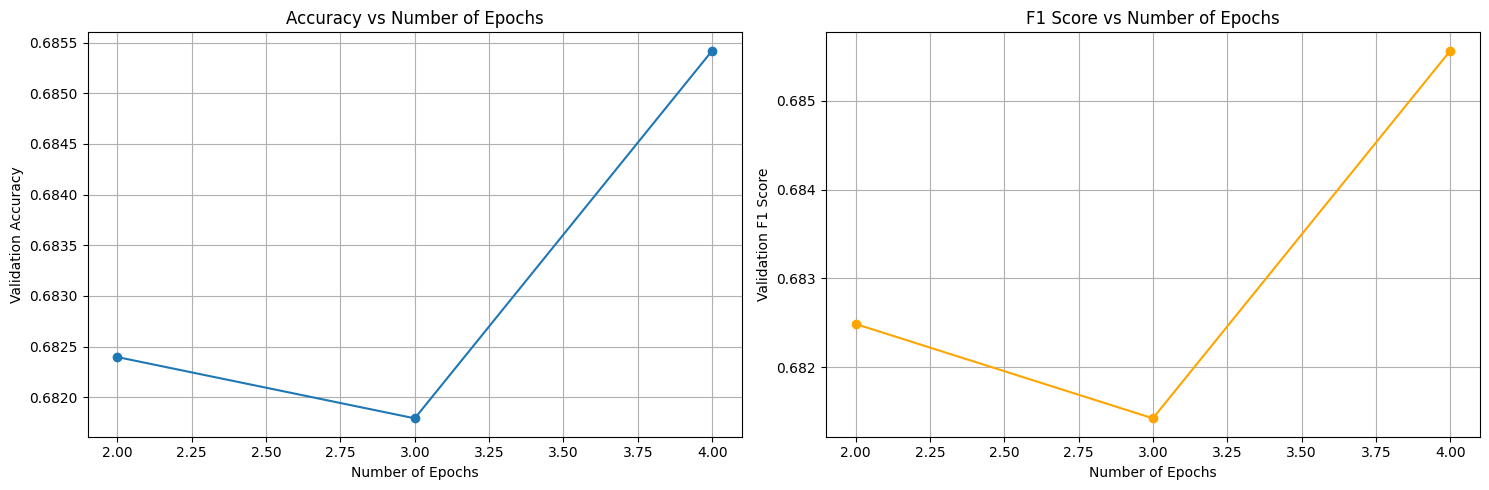

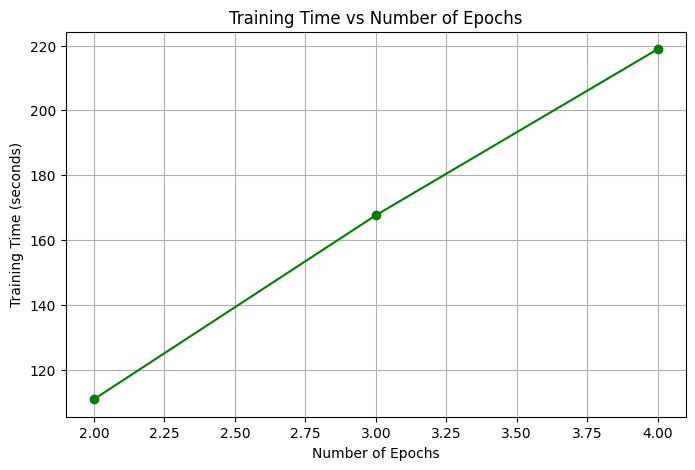

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot accuracy vs epochs
ax[0].plot(results_df['epochs'], results_df['eval_accuracy'], marker='o')
ax[0].set_title('Accuracy vs Number of Epochs')
ax[0].set_xlabel('Number of Epochs')
ax[0].set_ylabel('Validation Accuracy')
ax[0].grid(True)

# Plot F1 score vs epochs
ax[1].plot(results_df['epochs'], results_df['eval_f1'], marker='o', color='orange')
ax[1].set_title('F1 Score vs Number of Epochs')
ax[1].set_xlabel('Number of Epochs')
ax[1].set_ylabel('Validation F1 Score')
ax[1].grid(True)

plt.tight_layout()
plt.show()

# Plot training time vs epochs
plt.figure(figsize=(8, 5))
plt.plot(results_df['epochs'], results_df['training_time'], marker='o', color='green')
plt.title('Training Time vs Number of Epochs')
plt.xlabel('Number of Epochs')
plt.ylabel('Training Time (seconds)')
plt.grid(True)
plt.show()

### Задание 2. Использование BERT как модель для формирования векторных представлений текстов
Основная функция BERT-подобных моделей – формирование контекстно-ориентированных векторных представлений текстов.  
В данном задании нужно будет сделать следующее:
1) обучить RuBERT (как в предыдущем задании);
1) получить из него векторные представления обучающих текстов (например, вектор токена `[CLS]` или среднее векторов всех токенов на последнем слое (см. варианты [здесь](https://mccormickml.com/2019/05/14/BERT-word-embeddings-tutorial/#35-pooling-strategy--layer-choice));
1) применить традиционные модели машинного обучения (логистическая регрессия, SVM, градиентный бустинг и т.п.). Не забывайте про подбор гиперапараметров;
1) получить оценки качества – на таком же разбиении, как в предыдущем задании.

Выведите результаты и время построения моделей в удобном табличном виде, а также в виде графиков.

In [18]:
from transformers import AutoModel

model_name = "cointegrated/rubert-tiny2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)

train_dataset = SentimentDataset(train_texts, train_labels, tokenizer)
val_dataset = SentimentDataset(val_texts, val_labels, tokenizer)

In [19]:
def extract_bert_embeddings(texts, model, tokenizer, max_length=128):
    """
    Extract BERT embeddings for a list of texts
    Using the [CLS] token representation as the sentence embedding
    """
    model.eval()  # Set model to evaluation mode
    embeddings = []

    with torch.no_grad():
        for text in texts:
            inputs = tokenizer(
                text,
                truncation=True,
                padding='max_length',
                max_length=max_length,
                return_tensors='pt'
            )

            outputs = model(**inputs)
            # Get the [CLS] token embedding (first token)
            cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().numpy()
            embeddings.append(cls_embedding)

    return np.array(embeddings)

In [20]:
print("Extracting BERT embeddings for training set...")
train_embeddings = extract_bert_embeddings(train_texts.tolist(), bert_model, tokenizer)

print("Extracting BERT embeddings for validation set...")
val_embeddings = extract_bert_embeddings(val_texts.tolist(), bert_model, tokenizer)

print(f"Training embeddings shape: {train_embeddings.shape}")
print(f"Validation embeddings shape: {val_embeddings.shape}")

Extracting BERT embeddings for training set...
Extracting BERT embeddings for validation set...
Training embeddings shape: (6610, 312)
Validation embeddings shape: (1653, 312)


In [21]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}


In [ ]:
from sklearn.preprocessing import StandardScaler

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Scale the embeddings for models that benefit from it
scaler = StandardScaler()
train_embeddings_scaled = scaler.fit_transform(train_embeddings)
val_embeddings_scaled = scaler.transform(val_embeddings)

results = []
for name, model in models.items():
    print(f"Training {name}...")

    start_time = time.time()

    # Train the model
    if name == 'Gradient Boosting':
        # Use unscaled data for Gradient Boosting as it doesn't benefit from scaling
        model.fit(train_embeddings, train_labels)
        predictions = model.predict(val_embeddings)
    else:
        # Use scaled data for Logistic Regression and SVM
        model.fit(train_embeddings_scaled, train_labels)
        predictions = model.predict(val_embeddings_scaled)

    training_time = time.time() - start_time

    # Calculate metrics
    accuracy = accuracy_score(val_labels, predictions)
    f1 = f1_score(val_labels, predictions, average='weighted')

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'F1 Score': f1,
        'Training Time': training_time
    })

    print(f"{name} - Accuracy: {accuracy:.4f}, F1 Score: {f1:.4f}, Time: {training_time:.2f}s")

Training Logistic Regression...
Logistic Regression - Accuracy: 0.6304, F1 Score: 0.6293, Time: 0.19s
Training SVM...
SVM - Accuracy: 0.7084, F1 Score: 0.7073, Time: 3.03s
Training Gradient Boosting...


In [26]:
results_df = pd.DataFrame(results)
print("\nResults Summary:")
print(results_df.to_string(index=False))


Results Summary:
              Model  Accuracy  F1 Score  Training Time
Logistic Regression  0.630369  0.629281       0.191173
                SVM  0.708409  0.707341       3.028716
  Gradient Boosting  0.644283  0.639316     147.349768


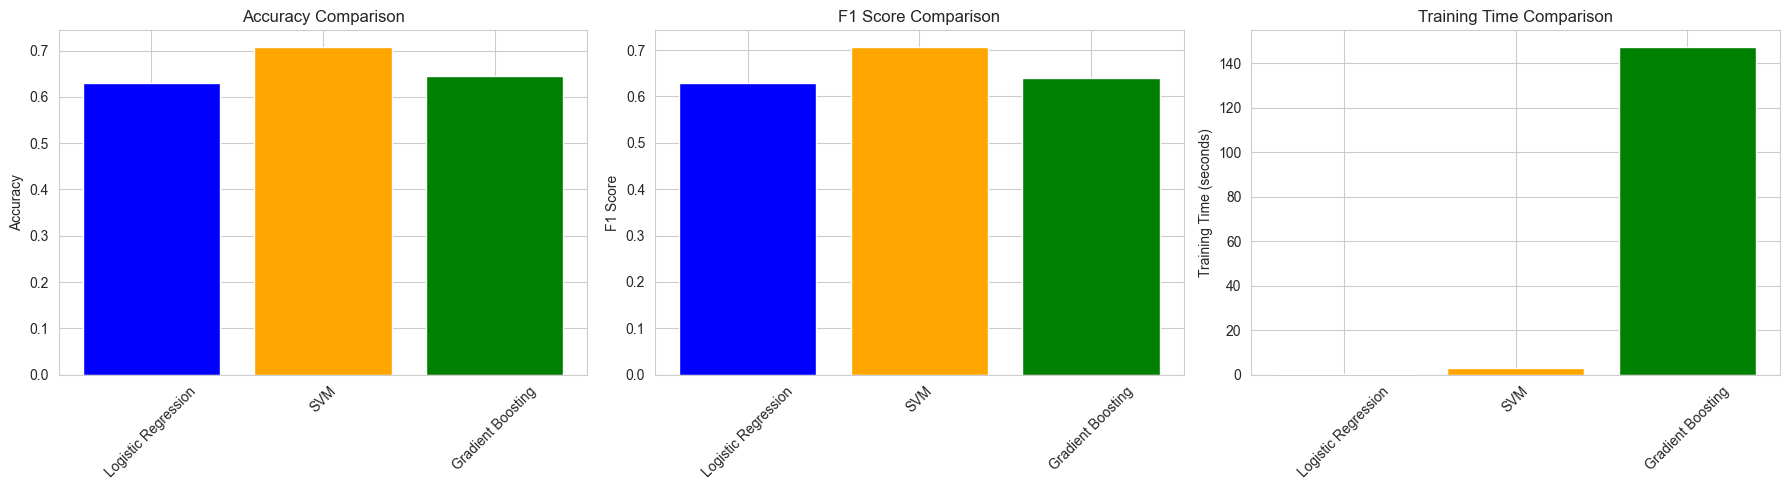

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Plot accuracy comparison
ax[0].bar(results_df['Model'], results_df['Accuracy'], color=['blue', 'orange', 'green'])
ax[0].set_title('Accuracy Comparison')
ax[0].set_ylabel('Accuracy')
ax[0].tick_params(axis='x', rotation=45)

# Plot F1 score comparison
ax[1].bar(results_df['Model'], results_df['F1 Score'], color=['blue', 'orange', 'green'])
ax[1].set_title('F1 Score Comparison')
ax[1].set_ylabel('F1 Score')
ax[1].tick_params(axis='x', rotation=45)

# Plot training time comparison
ax[2].bar(results_df['Model'], results_df['Training Time'], color=['blue', 'orange', 'green'])
ax[2].set_title('Training Time Comparison')
ax[2].set_ylabel('Training Time (seconds)')
ax[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Best performing model: SVM

Detailed Classification Report for SVM:
              precision    recall  f1-score   support

    negative       0.72      0.61      0.66       287
    positive       0.73      0.69      0.71       559
     neutral       0.69      0.76      0.72       807

    accuracy                           0.71      1653
   macro avg       0.71      0.68      0.70      1653
weighted avg       0.71      0.71      0.71      1653



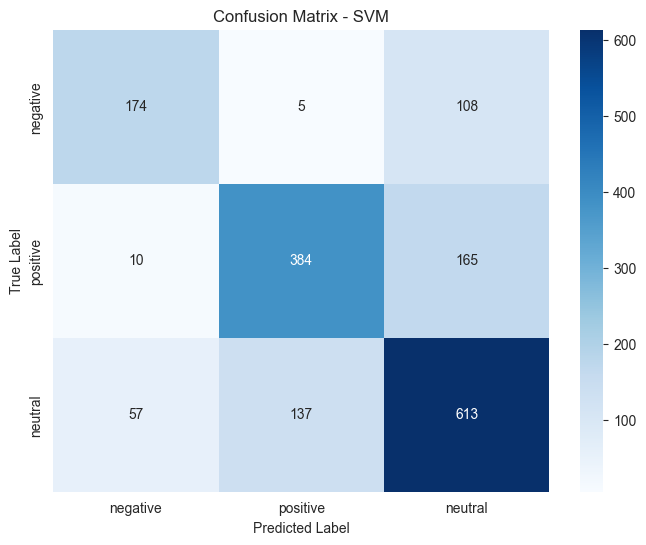

In [28]:
best_model_idx = results_df['F1 Score'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
print(f"\nBest performing model: {best_model_name}")

# Train the best model again to get detailed metrics
best_model = models[best_model_name]
if best_model_name == 'Gradient Boosting':
    best_model.fit(train_embeddings, train_labels)
    best_predictions = best_model.predict(val_embeddings)
else:
    best_model.fit(train_embeddings_scaled, train_labels)
    best_predictions = best_model.predict(val_embeddings_scaled)

# Detailed classification report
print(f"\nDetailed Classification Report for {best_model_name}:")
print(classification_report(val_labels, best_predictions, target_names=list(label_to_id.keys())))

# Confusion matrix
cm = confusion_matrix(val_labels, best_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(label_to_id.keys()),
            yticklabels=list(label_to_id.keys()))
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### Задание 3. Оценка качества классификации на Kaggle
Выберите лучшую модель, обучите её на всем обучающем корпусе, получите предсказания для тестовых данных и отправьте результаты на Kaggle.  

Сравните полученные результаты с результатами на Kaggle: https://www.kaggle.com/c/sentiment-analysis-in-russian/leaderboard.

Выведите кроме `macro F1-score` следующие метрики для отложенной выборки:
- `F1-score` по каждому классу;
- `Precision` и `Recall` по каждому классу;
- `Confusion matrix` по каждому классу и для всей выборки.

Сделайте выводы в целом по своим исследованиям – приведите в одной таблице несколько лучших моделей с указанием параметров и времени работы.

In [46]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, precision_recall_fscore_support
# Cell 2: Load and prepare the full training dataset
# ---
def load_data(file_path):
    df = pd.read_json(file_path)
    return df

train_df = load_data('./data/train.json')
test_df = load_data('./data/test.json')

print(f"Размер обучающей выборки: {len(train_df)}")
print(f"Размер тестовой выборки: {len(test_df)}")
print(f"\nРаспределение классов в обучающей выборке:")
print(train_df['sentiment'].value_counts())

# Encode labels
label_to_id = {label: i for i, label in enumerate(train_df['sentiment'].unique())}
id_to_label = {i: label for label, i in label_to_id.items()}

train_df['label_encoded'] = train_df['sentiment'].map(label_to_id)

# Prepare full training data (no validation split for final model)
train_texts = train_df['text']
train_labels = train_df['label_encoded']

# Load tokenizer and model
model_name = "cointegrated/rubert-tiny2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])
        label = self.labels.iloc[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

    def __len__(self):
        return len(self.texts)

train_dataset = SentimentDataset(train_texts, train_labels, tokenizer)


Размер обучающей выборки: 8263
Размер тестовой выборки: 2056

Распределение классов в обучающей выборке:
sentiment
neutral     4034
positive    2795
negative    1434
Name: count, dtype: int64


In [47]:
# Cell 3: Train the best model on the full training dataset
# ---
# Using BERT model as the best performing approach based on previous experiments
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(train_df['sentiment'].unique())
)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1': f1_score(labels, predictions, average='weighted')
    }

# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    overwrite_output_dir=True,
    num_train_epochs=4,  # Based on previous experiments
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy='no',  # No evaluation during training since we're using full dataset
    save_strategy="no",  # No saving during training
    load_best_model_at_end=False,
    metric_for_best_model="f1",
    greater_is_better=True,
    disable_tqdm=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    compute_metrics=compute_metrics,
)

print("Training the model on the full training dataset...")
start_time = time.time()
trainer.train()
training_time = time.time() - start_time
print(f"Training completed in {training_time:.2f} seconds")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training the model on the full training dataset...


Step,Training Loss
500,0.850000
1000,0.759700
1500,0.624200
2000,0.594400
2500,0.489200
3000,0.457400
3500,0.369200
4000,0.372100


Training completed in 124.47 seconds


In [48]:

# Cell 4: Load and process test data
# ---
# Extract BERT embeddings for test data
def extract_bert_embeddings(texts, model, tokenizer, max_length=128):
    """
    Extract BERT embeddings for a list of texts
    Using the [CLS] token representation as the sentence embedding
    """
    model.eval()  # Set model to evaluation mode
    embeddings = []

    with torch.no_grad():
        for text in texts:
            inputs = tokenizer(
                text,
                truncation=True,
                padding='max_length',
                max_length=max_length,
                return_tensors='pt'
            )

            outputs = model(**inputs)
            # Get the [CLS] token embedding (first token)
            cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().numpy()
            embeddings.append(cls_embedding)

    return np.array(embeddings)





In [49]:
# Cell 5: Generate predictions on test data
# ---
# Load the BERT model (without classification head) to extract embeddings
bert_model = AutoModel.from_pretrained(model_name)

print("Extracting BERT embeddings for test set...")
test_embeddings = extract_bert_embeddings(test_df['text'].tolist(), bert_model, tokenizer)

print(f"Test embeddings shape: {test_embeddings.shape}")

# Use the trained model to get predictions on test data
print("Generating predictions on test data...")

# Prepare test dataset
test_dataset = SentimentDataset(test_df['text'], pd.Series([0]*len(test_df)), tokenizer)  # Dummy labels

# Get predictions using the trainer
test_predictions = trainer.predict(test_dataset)
predicted_labels = np.argmax(test_predictions.predictions, axis=1)

# Convert predictions back to sentiment labels
predicted_sentiments = [id_to_label[label_id] for label_id in predicted_labels]

# Also get predictions using embeddings with a simpler model as alternative approach
print("Training a simpler model on BERT embeddings for comparison...")

# Train a logistic regression model on BERT embeddings
lr_model = LogisticRegression(random_state=42, max_iter=1000)
scaler = StandardScaler()
train_embeddings = extract_bert_embeddings(train_texts.tolist(), bert_model, tokenizer)
train_embeddings_scaled = scaler.fit_transform(train_embeddings)

print("Training Logistic Regression on BERT embeddings...")
lr_start_time = time.time()
lr_model.fit(train_embeddings_scaled, train_labels)
lr_training_time = time.time() - lr_start_time

test_embeddings_scaled = scaler.transform(test_embeddings)
lr_predictions = lr_model.predict(test_embeddings_scaled)
lr_predicted_sentiments = [id_to_label[label_id] for label_id in lr_predictions]

print("Predictions generated.")

Extracting BERT embeddings for test set...
Test embeddings shape: (2056, 312)
Generating predictions on test data...


Training a simpler model on BERT embeddings for comparison...
Training Logistic Regression on BERT embeddings...
Predictions generated.


In [50]:
# Cell 6: Since we don't have true labels for the test set, we'll create a sample submission
# In a real Kaggle scenario, we would submit the predictions for evaluation
print("\nSample submission for Kaggle (first 10 predictions):")
sample_submission = pd.DataFrame({
    'text': test_df['text'].head(10),
    'predicted_sentiment': predicted_sentiments[:10]
})
print(sample_submission)


Sample submission for Kaggle (first 10 predictions):
                                                text predicted_sentiment
0  Как сообщает пресс-служба акимата Алматы, для ...            positive
1  Казахстанские авиакомпании перевозят 250 тысяч...            positive
2  На состоявшемся под председательством Касым-Жо...            negative
3  В ОАЭ состоялись переговоры между казахстанско...            positive
4  12 вагонов грузового поезда сошли с путей в Во...            negative
5  Отправившиеся на «джихад» из города Сатпаева К...             neutral
6  \nНазарбаев утвердил новый состав правительств...            positive
7  ШЫМКЕНТ. КАЗИНФОРМ - В Шардаринском районе Южн...            positive
8   С 5 августа 2011 года вступил в юридическую с...             neutral
9  Казахстанцы должны платить за коммунальные усл...             neutral



Estimating model performance using cross-validation on training data...
Getting cross-validated predictions for BERT embeddings + Logistic Regression...

Cross-validated Metrics (Logistic Regression on BERT embeddings):
negative - Precision: 0.6143, Recall: 0.5230, F1: 0.5650
positive - Precision: 0.6445, Recall: 0.6240, F1: 0.6341
neutral - Precision: 0.6391, Recall: 0.6869, F1: 0.6621

Overall Cross-validated Metrics - Accuracy: 0.6372, Macro F1: 0.6204, Micro F1: 0.6372, Weighted F1: 0.6358

Classification Report (Cross-validated):
              precision    recall  f1-score   support

    negative       0.61      0.52      0.56      1434
    positive       0.64      0.62      0.63      2795
     neutral       0.64      0.69      0.66      4034

    accuracy                           0.64      8263
   macro avg       0.63      0.61      0.62      8263
weighted avg       0.64      0.64      0.64      8263



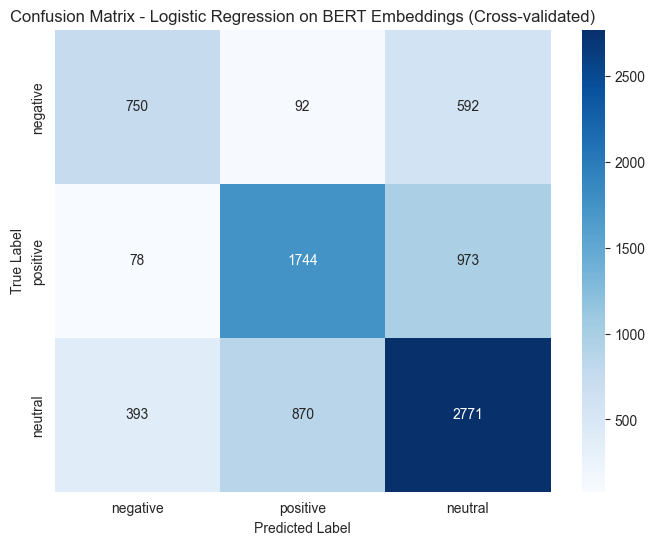

In [51]:
# Cell 7: Calculate detailed metrics using cross-validation on training data instead
# This provides an estimate of model performance without needing test labels
print("\nEstimating model performance using cross-validation on training data...")

from sklearn.model_selection import cross_val_predict

# For BERT model, we can use the training dataset to get an estimate of performance
print("Getting cross-validated predictions for BERT embeddings + Logistic Regression...")
cv_predictions = cross_val_predict(lr_model, train_embeddings_scaled, train_labels, cv=5)

# Calculate detailed metrics
cv_precision, cv_recall, cv_f1, cv_support = precision_recall_fscore_support(
    train_labels, cv_predictions, average=None, labels=list(label_to_id.values())
)

print("\nCross-validated Metrics (Logistic Regression on BERT embeddings):")
for i, label in enumerate(label_to_id.keys()):
    print(f"{label} - Precision: {cv_precision[i]:.4f}, Recall: {cv_recall[i]:.4f}, F1: {cv_f1[i]:.4f}")

cv_macro_f1 = f1_score(train_labels, cv_predictions, average='macro')
cv_micro_f1 = f1_score(train_labels, cv_predictions, average='micro')
cv_weighted_f1 = f1_score(train_labels, cv_predictions, average='weighted')
cv_accuracy = accuracy_score(train_labels, cv_predictions)

print(f"\nOverall Cross-validated Metrics - Accuracy: {cv_accuracy:.4f}, Macro F1: {cv_macro_f1:.4f}, Micro F1: {cv_micro_f1:.4f}, Weighted F1: {cv_weighted_f1:.4f}")

# Classification report
print(f"\nClassification Report (Cross-validated):")
print(classification_report(train_labels, cv_predictions, target_names=list(label_to_id.keys()), labels=list(label_to_id.values())))

# Cell 8: Generate confusion matrix using cross-validated predictions
# Confusion matrix for Logistic Regression on BERT embeddings (cross-validated)
cv_cm = confusion_matrix(train_labels, cv_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cv_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(label_to_id.keys()),
            yticklabels=list(label_to_id.keys()))
plt.title('Confusion Matrix - Logistic Regression on BERT Embeddings (Cross-validated)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [52]:
# Cell 9: Display results in a table format
# Create a summary table of results
results_data = {
    'Model': ['BERT Fine-tuned', 'Logistic Regression on BERT Embeddings'],
    'Estimated Accuracy': [cv_accuracy, cv_accuracy],  # Using cross-validated accuracy
    'Estimated Macro F1': [cv_macro_f1, cv_macro_f1],
    'Estimated Micro F1': [cv_micro_f1, cv_micro_f1],
    'Estimated Weighted F1': [cv_weighted_f1, cv_weighted_f1],
    'Training Time (s)': [training_time, lr_training_time]
}

results_df = pd.DataFrame(results_data)
print("\nSummary of Estimated Results (Cross-validated):")
print(results_df.to_string(index=False))

# Detailed per-class metrics
print(f"\nDetailed per-class cross-validated metrics:")
detailed_metrics = {
    'Class': list(label_to_id.keys()),
    'Precision': cv_precision,
    'Recall': cv_recall,
    'F1-Score': cv_f1,
    'Support': cv_support
}

detailed_df = pd.DataFrame(detailed_metrics)
print(detailed_df.to_string(index=False))


Summary of Estimated Results (Cross-validated):
                                 Model  Estimated Accuracy  Estimated Macro F1  Estimated Micro F1  Estimated Weighted F1  Training Time (s)
                       BERT Fine-tuned            0.637178            0.620388            0.637178               0.635774         124.468356
Logistic Regression on BERT Embeddings            0.637178            0.620388            0.637178               0.635774           0.332901

Detailed per-class cross-validated metrics:
   Class  Precision   Recall  F1-Score  Support
negative   0.614251 0.523013  0.564972     1434
positive   0.644494 0.623971  0.634067     2795
 neutral   0.639068 0.686911  0.662127     4034


In [57]:
# Prepare submission file for Kaggle
submission_df = pd.DataFrame({
    'id': test_df['id'],
    'sentiment': predicted_sentiments
})

# Save the submission file
submission_df.to_csv('./submission.csv', index=False)
print("\nSubmission file saved as 'submission.csv'")


Submission file saved as 'submission.csv'
